For making the final presentation plots that don't really fit anywhere else.

#1. Radar plots of our interests

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<Axes: title={'center': 'Where we started'}>

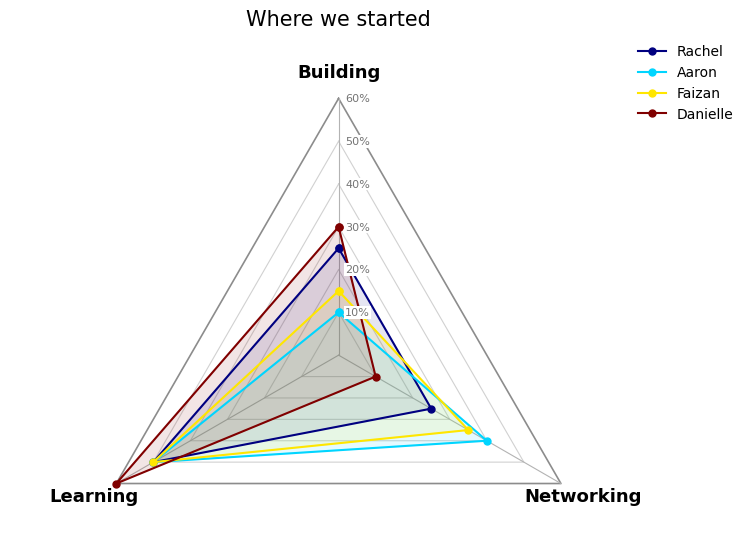

In [ ]:
def triangular_radar(data, categories=("Learning", "Networking", "Building"),
                     angles=(210, 330, 90), rmax=None, step=10, cmap="jet",
                     title=None, ax=None):
    """Triangular radar plot. `data` maps each name to 3 values.
    `angles` gives the vertex position in degrees for each category, in the
    same order as `categories` and the data values."""
    ang = np.deg2rad(angles)
    xy = lambda v: (np.asarray(v, float) * np.cos(ang), np.asarray(v, float) * np.sin(ang))
    close = lambda x, y: (np.append(x, x[0]), np.append(y, y[0]))
 
    if rmax is None:
        rmax = step * int(np.ceil(max(max(v) for v in data.values()) / step))
    if ax is None:
        ax = plt.subplots(figsize=(7.5, 6))[1]
    ax.set_aspect("equal"); ax.axis("off")
 
    order = np.argsort(ang % (2 * np.pi))                              # keep rings convex
    for r in np.arange(step, rmax + step, step):
        outer = np.isclose(r, rmax)
        rx, ry = xy([r] * 3)
        ax.plot(*close(rx[order], ry[order]), color="0.55" if outer else "0.82",
                lw=1.2 if outer else 0.8, zorder=1)
        ax.text(rmax * 0.025, r, f"{r:g}%", ha="left", va="center", fontsize=8,
                color="0.45", zorder=6,
                bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
 
    for a, lab in zip(ang, categories):                                # spokes + labels
        ax.plot([0, rmax * np.cos(a)], [0, rmax * np.sin(a)], color="0.7", lw=0.8, zorder=1)
        ax.text(1.1 * rmax * np.cos(a), 1.1 * rmax * np.sin(a), lab,
                ha="center", va="center", fontsize=13, fontweight="bold")
 
    for (name, vals), c in zip(data.items(), plt.get_cmap(cmap)(np.linspace(0, 1, len(data)))):
        vx, vy = xy(vals)
        px, py = close(vx[order], vy[order])
        ax.plot(px, py, color=c, lw=1.5, marker="o", ms=5, label=name, zorder=4)
        ax.fill(px, py, color=c, alpha=0.10, zorder=2)
 
    ax.set_xlim(-rmax * 1.28, rmax * 1.28); ax.set_ylim(-rmax * 0.72, rmax * 1.22)
    ax.legend(loc="upper right", bbox_to_anchor=(1.12, 1.02), frameon=False)
    if title:
        ax.set_title(title, fontsize=15, pad=12)
    plt.tight_layout()
    return ax

data = {
    "Rachel":   [50, 25, 25],
    "Aaron":    [50, 40, 10],
    "Faizan":   [50, 35, 15],
    "Danielle": [60, 10, 30],
}
 
triangular_radar(data, title="Where we started")

(<Figure size 1000x920 with 4 Axes>,
 array([<Axes: title={'center': 'Rachel'}>,
        <Axes: title={'center': 'Aaron'}>,
        <Axes: title={'center': 'Faizan'}>,
        <Axes: title={'center': 'Danielle'}>], dtype=object))

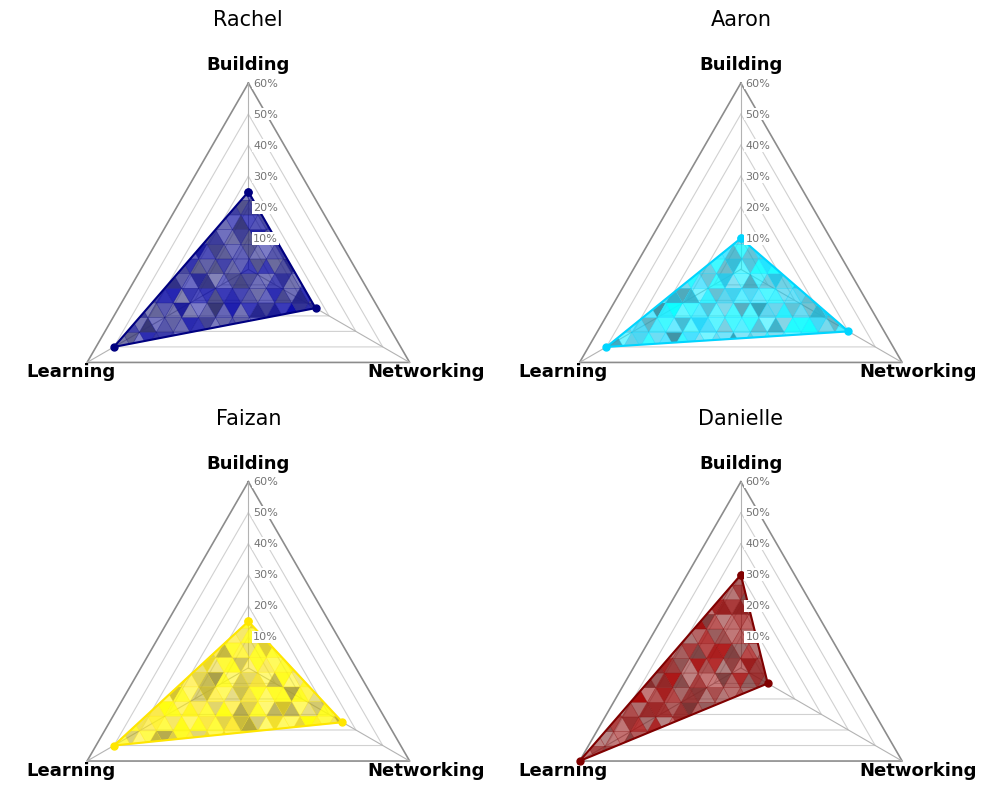

In [7]:
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection
from matplotlib.patches import Polygon
 
 
def _scale_fill(ax, verts, color, size, seed=0, alpha=(0.25, 0.95), zorder=3):
    """Tile the polygon `verts` with jittered triangles in shades of `color`."""
    rng = np.random.default_rng(seed)
    (xmin, ymin), (xmax, ymax) = verts.min(0), verts.max(0)
    s = size
    h = s * np.sqrt(3) / 2
 
    tris = []
    for j in range(int((ymax - ymin) / h) + 2):
        y0, off = ymin + j * h, (j % 2) * s / 2
        for i in range(-1, int((xmax - xmin) / s) + 2):
            x0 = xmin + i * s + off
            tris.append([(x0, y0), (x0 + s, y0), (x0 + s / 2, y0 + h)])
            tris.append([(x0 + s / 2, y0 + h), (x0 + 3 * s / 2, y0 + h), (x0 + s, y0)])
    tris = np.array(tris)
 
    base = np.array(mcolors.to_rgb(color))
    t = rng.random((len(tris), 1))
    face = np.clip(base * (0.60 + 0.75 * t) + 0.22 * (1 - t) * (1 - base), 0, 1)
    a = alpha[0] + (alpha[1] - alpha[0]) * rng.random((len(tris), 1))
 
    clip = Polygon(verts, transform=ax.transData, fc="none", ec="none")
    ax.add_patch(clip)
    under = Polygon(verts, fc=color, alpha=0.35, ec="none", zorder=zorder - 0.5)
    ax.add_patch(under)                                # hides grid under the scales
    pc = PolyCollection(tris, facecolors=np.hstack([face, a]),
                        edgecolors=mcolors.to_rgba(color, 0.30), lw=0.4, zorder=zorder)
    pc.set_clip_path(clip)
    ax.add_collection(pc)
    return pc
 
 
def triangular_radar_panels(data, categories=("Learning", "Networking", "Building"),
                            angles=(210, 330, 90), rmax=None, step=10, cmap="jet",
                            ncols=2, scale_n=11, suptitle=None, panel_size=(5.0, 4.6)):
    """One panel per participant, colours matched to triangular_radar's jet order."""
    names = list(data)
    if rmax is None:                                   # shared scale across panels
        rmax = step * int(np.ceil(max(max(v) for v in data.values()) / step))
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(names)))
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel_size[0] * ncols, panel_size[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
 
    for k, (name, c) in enumerate(zip(names, colors)):
        ax = axes[k]
        triangular_radar({name: data[name]}, categories=categories, angles=angles,
                         rmax=rmax, step=step, ax=ax, title=name)
        if ax.get_legend():
            ax.get_legend().remove()
        ax.lines[-1].set_color(c)                      # outline + markers
        fill = ax.patches[-1]
        verts = fill.get_xy()[:-1]
        fill.set_facecolor("none")                     # replace flat fill with scales
        _scale_fill(ax, verts, c, size=rmax / scale_n, seed=k)
 
    for ax in axes[len(names):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, y=1.0)
    fig.tight_layout()
    return fig, axes
 
 
data = {
    "Rachel":   [50, 25, 25],
    "Aaron":    [50, 40, 10],
    "Faizan":   [50, 35, 15],
    "Danielle": [60, 10, 30],
}
triangular_radar_panels(data, suptitle=None)
